<a href="https://colab.research.google.com/github/jcmachicao/IA_politicaspublicas/blob/main/aipp___ejemplo_sencillo_RL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aplicando el Aprendizaje por Refuerzo a la Iluminación Pública

Un ejemplo de cómo el RL puede ser aplicado a problemas de políticas públicas. Los componentes clave para modelar este problema:

## 1. El Agente (Agent)
El agente sería el sistema de control que toma decisiones sobre la iluminación de los espacios públicos. Su objetivo es maximizar una recompensa acumulada a lo largo del tiempo, equilibrando factores como el ahorro de energía/presupuesto, la seguridad y el bienestar ciudadano.

## 2. El Entorno (Environment)
El entorno es el espacio público (una calle, un parque, una plaza) con sus dinámicas. Incluye factores como la hora del día, las condiciones climáticas, la presencia de personas, los eventos, el historial de criminalidad, etc.

## 3. El Estado (State)
El estado (observación) que el agente percibe del entorno en un momento dado. Este debe contener toda la información relevante para que el agente tome una buena decisión. Podría incluir:
*   **Hora del día/Noche:** Fundamental para decidir si encender las luces.
*   **Condiciones climáticas:** Lluvia, niebla, oscuridad natural adicional.
*   **Nivel de luz ambiental:** Sensores de luz natural.
*   **Presencia de personas:** Detectores de movimiento, cámaras (anonimizadas).
*   **Nivel de actividad:** Datos históricos o en tiempo real de uso del espacio.
*   **Índices de seguridad:** Datos históricos de incidentes en la zona.
*   **Presupuesto disponible:** Restricciones o saldo actual del presupuesto energético.
*   **Estado actual de las luces:** Encendidas/Apagadas, nivel de intensidad.

**Ejemplo de estado:**

`[hora_actual, es_noche, hay_lluvia, personas_detectadas, indice_criminalidad_zona, presupuesto_restante, luz_actualmente_encendida]`

## 4. Las Acciones (Actions)
Las acciones que el agente puede tomar para influir en el entorno. Podrían ser:
*   **Encender/Apagar las luces:** Una acción binaria.
*   **Ajustar la intensidad:** Niveles discretos o continuos de brillo.
*   **Mantener el estado actual:** No hacer nada.
*   **Ajustar horarios preestablecidos:** Modificar un horario programado.

**Ejemplo de acciones:**

`[encender, apagar, aumentar_intensidad, disminuir_intensidad, no_hacer_nada]`

## 5. La Recompensa (Reward)
La recompensa es la señal que el agente recibe del entorno después de realizar una acción, indicando cuán buena fue esa acción. Se construye combinando los objetivos de la política pública:
*   **Recompensa Positiva:**
    *   `+1` por seguridad (si la iluminación disuade el crimen, o si la presencia de luz se correlaciona con menos incidentes).
    *   `+1` por bienestar (si la gente usa más el espacio o se siente más segura).
    *   `+0.5` por uso eficiente (si las luces están encendidas cuando hay gente presente y son necesarias).
*   **Recompensa Negativa (Castigo):**
    *   `-X` por consumo de energía/presupuesto (un costo por mantener las luces encendidas, proporcional al tiempo y la intensidad).
    *   `-Y` por inseguridad (si las luces están apagadas y ocurre un incidente, o si la oscuridad contribuye a la percepción de inseguridad).
    *   `-Z` por disconfort (luces encendidas sin necesidad, generando contaminación lumínica o molestia).

La función de recompensa sería una suma ponderada de estos factores. Por ejemplo:

`reward = (seguridad_score * w1) + (bienestar_score * w2) - (costo_energia * w3) - (riesgo_inseguridad * w4)`

## 6. La Política (Policy)
La política es la estrategia que el agente usa para seleccionar una acción dado un estado. El objetivo del entrenamiento de RL es aprender la política óptima que maximice la recompensa acumulada a largo plazo.

## Desafíos y Consideraciones:
*   **Recopilación de Datos:** Necesitarías datos históricos y en tiempo real para el estado y para evaluar la recompensa (ej. sensores de presencia, medidores de energía, reportes de incidentes, encuestas de percepción).
*   **Simulación:** Sería ideal construir un entorno de simulación para entrenar al agente antes de implementarlo en el mundo real, dadas las implicaciones de seguridad y presupuesto.
*   **Exploración vs. Explotación:** El agente debe equilibrar entre explorar nuevas estrategias de iluminación y explotar las que ya sabe que funcionan bien.
*   **Multi-objetivo:** La función de recompensa debe ser cuidadosamente diseñada para balancear los objetivos a menudo conflictivos de presupuesto, seguridad y bienestar.

Este es un caso de uso muy prometedor para el RL en políticas públicas. ¡Definitivamente es una gran idea para explorar!'''

## 7. Definición de Clases Básicas para el Modelo RL

In [30]:
import random

class Environment:
    def __init__(self):
        # Inicializar el estado del entorno (e.g., hora, clima, presencia de personas)
        self.current_state = self._get_initial_state()

    def _get_initial_state(self):
        # Define el estado inicial del entorno. Esto es un ejemplo.
        # [hora_actual, es_noche, hay_lluvia, personas_detectadas, indice_criminalidad_zona, presupuesto_restante, luz_actualmente_encendida]
        return State(hour=18, is_night=True, raining=False, people_detected=5, crime_index=0.1, budget=1000, light_on=False, intensity=0)

    def step(self, action):
        # Aplica una acción y actualiza el estado del entorno, calcula la recompensa
        old_state = self.current_state
        new_state = self._update_state(old_state, action)
        reward = self._calculate_reward(old_state, action, new_state)
        self.current_state = new_state
        done = self._is_terminal(new_state) # Define si el episodio ha terminado
        return new_state, reward, done

    def _update_state(self, old_state, action):
        # Lógica para actualizar el estado basada en la acción
        # Esto es un placeholder; la lógica real sería más compleja
        new_hour = (old_state.hour + 1) % 24
        new_light_on = old_state.light_on
        new_intensity = old_state.intensity

        if action.type == 'turn_on':
            new_light_on = True
            new_intensity = action.value if action.value is not None else 100 # Asume intensidad máxima por defecto
        elif action.type == 'turn_off':
            new_light_on = False
            new_intensity = 0
        elif action.type == 'adjust_intensity':
            new_intensity = action.value
            new_light_on = (new_intensity > 0)

        # Simular algunos cambios aleatorios en el entorno para el ejemplo
        new_people_detected = max(0, old_state.people_detected + random.randint(-2, 2))
        new_crime_index = max(0.0, min(1.0, old_state.crime_index + random.uniform(-0.05, 0.05)))
        new_budget = old_state.budget - (new_intensity * 0.1) # Costo simplificado

        return State(
            hour=new_hour,
            is_night=(new_hour < 6 or new_hour > 18),
            raining=old_state.raining, # Podría cambiar con el tiempo
            people_detected=new_people_detected,
            crime_index=new_crime_index,
            budget=new_budget,
            light_on=new_light_on,
            intensity=new_intensity
        )

    def _calculate_reward(self, old_state, action, new_state):
        # Implementar la función de recompensa ponderada aquí
        # reward = (seguridad_score * w1) + (bienestar_score * w2) - (costo_energia * w3) - (riesgo_inseguridad * w4)
        reward = 0

        # Penalización base por costo de luz
        cost_of_light = (new_state.intensity * 0.1)
        reward -= cost_of_light

        # Recompensas/Penalizaciones relacionadas con la seguridad y bienestar
        # Aumentamos el peso de tener las luces encendidas cuando hay gente y es de noche
        if new_state.is_night and new_state.people_detected > 0:
            if new_state.light_on:
                reward += 2.0  # Mayor recompensa por seguridad y bienestar cuando es necesario
            else:
                reward -= 1.5  # Mayor penalización por no encender las luces cuando hay gente y es de noche

        # Penalización si las luces están encendidas sin necesidad (ej. sin gente o de día)
        if new_state.light_on and (new_state.people_detected == 0 or not new_state.is_night):
            reward -= 0.7  # Penalización por desperdicio de energía/contaminación lumínica

        # Recompensa por ahorro cuando no hay nadie y es de noche
        if not new_state.light_on and new_state.people_detected == 0 and new_state.is_night:
            reward += 0.5

        # Recompensas/Penalizaciones relacionadas con el crimen
        if new_state.crime_index < old_state.crime_index:
            reward += 0.3 # Mayor recompensa por reducción del crimen
        elif new_state.crime_index > old_state.crime_index:
            reward -= 0.3 # Mayor penalización por aumento del crimen

        return reward

    def _is_terminal(self, state):
        # Define cuándo termina un episodio (e.g., presupuesto agotado, tiempo límite)
        return state.budget <= 0 or state.hour == 23 # Ejemplo: fin del día o sin presupuesto

    def reset(self):
        self.current_state = self._get_initial_state()
        return self.current_state

    def render(self):
        print(f"Current State: {self.current_state}")

In [10]:
class State:
    def __init__(self, hour, is_night, raining, people_detected, crime_index, budget, light_on, intensity):
        self.hour = hour
        self.is_night = is_night
        self.raining = raining
        self.people_detected = people_detected
        self.crime_index = crime_index
        self.budget = budget
        self.light_on = light_on
        self.intensity = intensity

    def __repr__(self):
        return (
            f"State(Hour={self.hour}, Night={self.is_night}, Rain={self.raining}, "
            f"People={self.people_detected}, Crime={self.crime_index:.2f}, "
            f"Budget={self.budget:.2f}, LightOn={self.light_on}, Intensity={self.intensity})"
        )

    def to_tuple(self):
        # Convierte el estado a una tupla inmutable para usarlo como clave en diccionarios (Q-table)
        return (self.hour, self.is_night, self.raining, self.people_detected,
                round(self.crime_index, 1), round(self.budget, 0), self.light_on, self.intensity)

In [11]:
class Action:
    def __init__(self, type, value=None):
        # type puede ser 'turn_on', 'turn_off', 'adjust_intensity', 'do_nothing'
        # value se usa para 'adjust_intensity' (e.g., 0-100)
        self.type = type
        self.value = value

    def __repr__(self):
        if self.value is not None:
            return f"Action({self.type}, value={self.value})"
        return f"Action({self.type})"

    def __eq__(self, other):
        if not isinstance(other, Action):
            return NotImplemented
        return self.type == other.type and self.value == other.value

    def __hash__(self):
        return hash((self.type, self.value))

In [12]:
class Agent:
    def __init__(self, environment):
        self.environment = environment
        self.possible_actions = self._get_possible_actions() # Lista de todas las acciones posibles

    def _get_possible_actions(self):
        # Define todas las acciones discretas que el agente puede tomar
        actions = [
            Action('turn_on', 100), # Encender al 100%
            Action('turn_off'),
            Action('adjust_intensity', 25),
            Action('adjust_intensity', 50),
            Action('adjust_intensity', 75),
            Action('do_nothing')
        ]
        return actions

    def choose_action(self, state):
        # Esta es la parte central del agente RL. En un agente real,
        # usaría una política (ej. Q-table, red neuronal) para elegir la acción.
        # Por ahora, elegiremos una acción aleatoria para el ejemplo.
        return random.choice(self.possible_actions)

    def learn(self, old_state, action, reward, new_state, done):
        # En un agente real, aquí se actualizarían los pesos de la red neuronal
        # o los valores de la Q-table basados en la experiencia (old_state, action, reward, new_state)
        pass

## 8. Implementación del Agente Q-Learning

# New Section

In [13]:
import numpy as np
from collections import defaultdict

class QLearningAgent(Agent):
    def __init__(self, environment, learning_rate=0.1, discount_factor=0.9, epsilon=0.1, epsilon_decay_rate=0.995, min_epsilon=0.01):
        super().__init__(environment)
        self.q_table = defaultdict(lambda: np.zeros(len(self.possible_actions))) # Q-table: (state_tuple) -> [q_value_action1, ...]
        self.learning_rate = learning_rate  # Alpha
        self.discount_factor = discount_factor # Gamma
        self.epsilon = epsilon  # Epsilon para la política epsilon-greedy
        self.epsilon_decay_rate = epsilon_decay_rate
        self.min_epsilon = min_epsilon

    def choose_action(self, state):
        state_tuple = state.to_tuple()
        # Política epsilon-greedy
        if random.uniform(0, 1) < self.epsilon:
            # Exploración: elige una acción aleatoria
            return random.choice(self.possible_actions)
        else:
            # Explotación: elige la acción con el mayor Q-value
            q_values = self.q_table[state_tuple]
            # Encontrar el índice de la acción con el Q-value máximo
            max_q = -float('inf')
            best_action_indices = []
            for i, q_val in enumerate(q_values):
                if q_val > max_q:
                    max_q = q_val
                    best_action_indices = [i]
                elif q_val == max_q:
                    best_action_indices.append(i)

            # Si hay múltiples acciones con el mismo Q-value máximo, elige una al azar
            chosen_action_index = random.choice(best_action_indices)
            return self.possible_actions[chosen_action_index]

    def learn(self, old_state, action, reward, new_state, done):
        old_state_tuple = old_state.to_tuple()
        new_state_tuple = new_state.to_tuple()

        # Encuentra el índice de la acción tomada en la lista de acciones posibles
        action_index = self.possible_actions.index(action)

        # Q(s,a) = Q(s,a) + alpha * [reward + gamma * max(Q(s',a')) - Q(s,a)]
        old_q_value = self.q_table[old_state_tuple][action_index]

        if done:
            # Si es un estado terminal, no hay futuro (max(Q(s',a')) = 0)
            max_future_q = 0
        else:
            # Estima el valor Q máximo para el nuevo estado
            max_future_q = np.max(self.q_table[new_state_tuple])

        new_q_value = old_q_value + self.learning_rate * (reward + self.discount_factor * max_future_q - old_q_value)
        self.q_table[old_state_tuple][action_index] = new_q_value

        # Decay epsilon
        if done:
            self.epsilon = max(self.min_epsilon, self.epsilon * self.epsilon_decay_rate)

## 9. Simulación de Entrenamiento

Episode 0: Total Reward = -27.4, Epsilon = 0.0995
Episode 50000: Total Reward = 0.1, Epsilon = 0.0100
Episode 100000: Total Reward = 0.09999999999999998, Epsilon = 0.0100
Episode 150000: Total Reward = -0.2, Epsilon = 0.0100
Episode 200000: Total Reward = 0.9, Epsilon = 0.0100
Episode 250000: Total Reward = 0.10000000000000003, Epsilon = 0.0100
Episode 300000: Total Reward = 0.4, Epsilon = 0.0100
Episode 350000: Total Reward = 0.7000000000000001, Epsilon = 0.0100
Episode 400000: Total Reward = 0.4, Epsilon = 0.0100
Episode 450000: Total Reward = 0.40000000000000013, Epsilon = 0.0100
Episode 500000: Total Reward = 0.6000000000000001, Epsilon = 0.0100
Episode 550000: Total Reward = -0.2, Epsilon = 0.0100
Episode 600000: Total Reward = 0.10000000000000003, Epsilon = 0.0100
Episode 650000: Total Reward = 0.4, Epsilon = 0.0100
Episode 700000: Total Reward = -0.5, Epsilon = 0.0100
Episode 750000: Total Reward = 0.09999999999999998, Epsilon = 0.0100
Episode 800000: Total Reward = 0.1, Epsilon

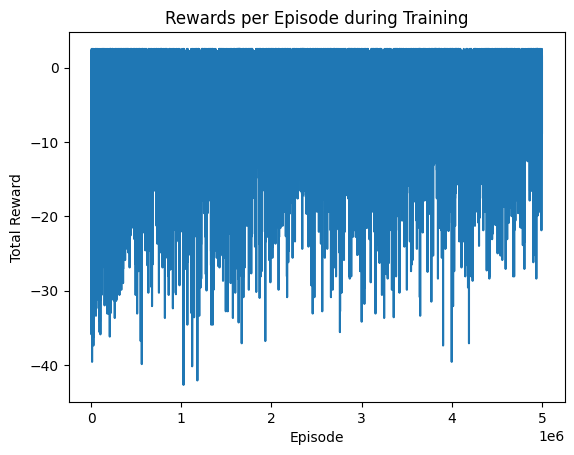


Demostración del agente entrenado:
Current State: State(Hour=18, Night=True, Rain=False, People=5, Crime=0.10, Budget=1000.00, LightOn=False, Intensity=0)
Agent chooses: Action(do_nothing)
New state: State(Hour=19, Night=True, Rain=False, People=7, Crime=0.05, Budget=1000.00, LightOn=False, Intensity=0), Reward: 0.20, Done: False

Current State: State(Hour=19, Night=True, Rain=False, People=7, Crime=0.05, Budget=1000.00, LightOn=False, Intensity=0)
Agent chooses: Action(do_nothing)
New state: State(Hour=20, Night=True, Rain=False, People=9, Crime=0.01, Budget=1000.00, LightOn=False, Intensity=0), Reward: 0.20, Done: False

Current State: State(Hour=20, Night=True, Rain=False, People=9, Crime=0.01, Budget=1000.00, LightOn=False, Intensity=0)
Agent chooses: Action(turn_off)
New state: State(Hour=21, Night=True, Rain=False, People=8, Crime=0.02, Budget=1000.00, LightOn=False, Intensity=0), Reward: -0.10, Done: False

Current State: State(Hour=21, Night=True, Rain=False, People=8, Crime=0

In [26]:
env = Environment()
agent = QLearningAgent(env)

num_episodes = 5000000
rewards_per_episode = []

for episode in range(num_episodes):
    state = env.reset()
    done = False
    total_reward = 0

    while not done:
        action = agent.choose_action(state)
        new_state, reward, done = env.step(action)
        agent.learn(state, action, reward, new_state, done)
        state = new_state
        total_reward += reward

    rewards_per_episode.append(total_reward)
    if episode % 50000 == 0:
        print(f"Episode {episode}: Total Reward = {total_reward}, Epsilon = {agent.epsilon:.4f}")

print("\nEntrenamiento terminado.")

# Opcional: Visualizar los resultados del entrenamiento
import matplotlib.pyplot as plt

plt.plot(rewards_per_episode)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Rewards per Episode during Training")
plt.show()



In [27]:
# Demostrar el agente entrenado
print("\nDemostración del agente entrenado:")
agent.epsilon = 0 # Desactivar exploración para la demostración
state = env.reset()
done = False

while not done:
    env.render()
    action = agent.choose_action(state)
    print(f"Agent chooses: {action}")
    new_state, reward, done = env.step(action)
    state = new_state
    print(f"New state: {state}, Reward: {reward:.2f}, Done: {done}\n")
    if state.budget <= 0:
      print("Presupuesto agotado. Fin de la demostración.")
      break
    if state.hour >= 23:
      print("Fin del día. Fin de la demostración.")
      break


Demostración del agente entrenado:
Current State: State(Hour=18, Night=True, Rain=False, People=5, Crime=0.10, Budget=1000.00, LightOn=False, Intensity=0)
Agent chooses: Action(do_nothing)
New state: State(Hour=19, Night=True, Rain=False, People=4, Crime=0.11, Budget=1000.00, LightOn=False, Intensity=0), Reward: -0.10, Done: False

Current State: State(Hour=19, Night=True, Rain=False, People=4, Crime=0.11, Budget=1000.00, LightOn=False, Intensity=0)
Agent chooses: Action(do_nothing)
New state: State(Hour=20, Night=True, Rain=False, People=2, Crime=0.07, Budget=1000.00, LightOn=False, Intensity=0), Reward: 0.20, Done: False

Current State: State(Hour=20, Night=True, Rain=False, People=2, Crime=0.07, Budget=1000.00, LightOn=False, Intensity=0)
Agent chooses: Action(turn_off)
New state: State(Hour=21, Night=True, Rain=False, People=3, Crime=0.09, Budget=1000.00, LightOn=False, Intensity=0), Reward: -0.10, Done: False

Current State: State(Hour=21, Night=True, Rain=False, People=3, Crime=

## 10. Extracción e Interpretación de la Política Aprendida

In [28]:
import pandas as pd

# Crear una lista para almacenar los datos de la política
policy_data = []

# Iterar sobre la q_table para extraer el estado, la acción óptima y su Q-value
for state_tuple, q_values_array in agent.q_table.items():
    # Encontrar el índice de la acción con el mayor Q-value
    best_action_index = np.argmax(q_values_array)
    optimal_action = agent.possible_actions[best_action_index]
    max_q_value = q_values_array[best_action_index]

    # Reconstruir el estado a partir de la tupla
    state = State(*state_tuple) # Asumiendo que la tupla del estado se puede desempaquetar así

    policy_data.append({
        'Hour': state.hour,
        'Is_Night': state.is_night,
        'Raining': state.raining,
        'People_Detected': state.people_detected,
        'Crime_Index': state.crime_index,
        'Budget': state.budget,
        'Light_On': state.light_on,
        'Intensity': state.intensity,
        'Optimal_Action_Type': optimal_action.type,
        'Optimal_Action_Value': optimal_action.value,
        'Max_Q_Value': max_q_value
    })

# Crear un DataFrame de Pandas
policy_df = pd.DataFrame(policy_data)

# Mostrar las primeras filas del DataFrame de la política
display(policy_df.head())

# Mostrar el tamaño de la política aprendida (cuántos estados únicos se exploraron)
print(f"Tamaño de la política aprendida (estados únicos): {len(policy_df)}")


,Hour,Is_Night,Raining,People_Detected,Crime_Index,Budget,Light_On,Intensity,Optimal_Action_Type,Optimal_Action_Value,Max_Q_Value
0,18,True,False,5,0.1,1000.0,False,0,do_nothing,NaN,0.160644
1,19,True,False,5,0.1,995.0,True,50,turn_off,NaN,0.218996
2,20,True,False,3,0.1,992.0,True,25,turn_off,NaN,0.018480
3,21,True,False,5,0.2,985.0,True,75,turn_on,100.0,0.000000
4,22,True,False,7,0.1,978.0,True,75,adjust_intensity,25.0,0.000000


Tamaño de la política aprendida (estados únicos): 2946


### Ejemplo de Interpretación y Recomendación Narrativa

In [32]:
from IPython.display import Markdown

# Filtrar el DataFrame para un escenario específico de interés
# Por ejemplo: de noche, con gente presente, y un índice de criminalidad moderado.

scenario_filter = (
    (policy_df['Is_Night'] == True) &
    (policy_df['People_Detected'] > 3) &
    (policy_df['Crime_Index'] > 0.05) &
    (policy_df['Budget'] > 0)
)

scenario_df = policy_df[scenario_filter]

if not scenario_df.empty:
    # Contar las acciones óptimas en este escenario
    action_counts = scenario_df['Optimal_Action_Type'].value_counts()

    print("Acciones óptimas más frecuentes para este escenario:")
    print(action_counts)
    print("\n")

    # Seleccionar la acción más común (o una específica si hay varias) para la narrativa
    most_common_action = action_counts.index[0]

    # Construir la narrativa
    narrative = f"**Recomendación de Política de Iluminación:**\n\nCuando es **de noche**, hay una **cantidad significativa de personas** en el espacio público (más de 3 detectadas) y el **índice de criminalidad es moderado a alto** (mayor a 0.05), el agente de RL recomienda **'{most_common_action}'** las luces para maximizar la recompensa general (considerando seguridad, bienestar y presupuesto)."

    if most_common_action == 'turn_on':
        narrative += " Se prioriza la seguridad y el bienestar percibido ante la presencia de usuarios."
    elif most_common_action == 'adjust_intensity':
        optimal_intensity = scenario_df[scenario_df['Optimal_Action_Type'] == 'adjust_intensity']['Optimal_Action_Value'].mode().iloc[0]
        narrative += f" Se sugiere un ajuste de intensidad a {optimal_intensity}% para equilibrar el ahorro y la necesidad de visibilidad."
    elif most_common_action == 'turn_off':
        narrative += " A pesar de la presencia de personas, el agente puede haber encontrado que apagar las luces es óptimo, posiblemente debido a una alta penalización por consumo de energía o un bajo impacto percibido en la seguridad en las condiciones modeladas, o la ausencia de incidentes recientes."
    elif most_common_action == 'do_nothing':
        narrative += " El agente considera que la configuración actual de las luces es adecuada, evitando cambios innecesarios y optimizando el uso de recursos."

    display(Markdown(narrative))
else:
    print("No se encontraron estados que coincidan con el escenario filtrado.")

Acciones óptimas más frecuentes para este escenario:
Optimal_Action_Type
turn_off            757
turn_on             436
do_nothing          168
adjust_intensity     60
Name: count, dtype: int64




**Recomendación de Política de Iluminación:**

Cuando es **de noche**, hay una **cantidad significativa de personas** en el espacio público (más de 3 detectadas) y el **índice de criminalidad es moderado a alto** (mayor a 0.05), el agente de RL recomienda **'turn_off'** las luces para maximizar la recompensa general (considerando seguridad, bienestar y presupuesto). A pesar de la presencia de personas, el agente puede haber encontrado que apagar las luces es óptimo, posiblemente debido a una alta penalización por consumo de energía o un bajo impacto percibido en la seguridad en las condiciones modeladas, o la ausencia de incidentes recientes.